In [1499]:
from dataclasses import dataclass

@dataclass
class Grid:
    rows: int
    cols: int
    step_reward: int
    terminals: dict
    walls: set
    steps_count: int = 0
    actions = dict(up=(-1, 0), right=(0, 1), down=(1, 0), left=(0, -1))
    arrows = {'up': "↑", 'right': "→", 'down': "↓", 'left': "←"}
    def reset(self):
        self.steps_count = 0
    def cell_repr(self, r, c):
        cell = (r, c)
        if cell in self.terminals:
            return self.terminals[cell]
        elif cell in self.walls:
            return '#'
        else:
            return '·'
    def render(self):
        for r in range(self.rows):
            for c in range(self.cols):
                print(f'{self.cell_repr(r, c):>3} ', end="")
            print()

    def step(self, cell, action):
        self.steps_count += 1
        movement = self.actions[action]
        next_cell = (cell[0] + movement[0], cell[1] + movement[1])
        outside = not (0 <= next_cell[0] < self.rows and 0 <= next_cell[1] < self.cols)
        on_wall = next_cell in self.walls
        if outside or on_wall:
            next_cell = cell

        if next_cell in self.terminals:
            reward = self.terminals[next_cell]
        else:
            reward = self.step_reward
        return next_cell, reward
    def properties(self):
        return f'''
Grid(
    rows={self.rows},
    cols={self.cols},
    step_reward={self.step_reward},
    terminals={self.terminals},
    walls={self.walls},
)
'''


default_grid = Grid(
    rows=3,
    cols=4,
    step_reward=0,
    terminals={(0, 3): 1},
    walls={(1, 1)},
)
default_grid

Grid(rows=3, cols=4, step_reward=0, terminals={(0, 3): 1}, walls={(1, 1)}, steps_count=0)

In [1500]:
print(default_grid.properties())


Grid(
    rows=3,
    cols=4,
    step_reward=0,
    terminals={(0, 3): 1},
    walls={(1, 1)},
)



In [1501]:
default_grid.render()

  ·   ·   ·   1 
  ·   #   ·   · 
  ·   ·   ·   · 


In [1502]:
cell = (0, 0)
for _ in range(3):
    cell, reward = default_grid.step(cell, 'right')
    print((cell, reward))


((0, 1), 0)
((0, 2), 0)
((0, 3), 1)


In [1503]:
def show_V(grid: Grid, V):
    for r in range(grid.rows):
        for c in range(grid.cols):
            print(f'{round(V[r][c], 2):>4} ', end="")
        print()
    print('------------------')

    
def value_iteration(grid: Grid, gamma = 0.9):
    V = [[0 for _ in range(grid.cols)] for _ in range(grid.rows)]
    delta = 1e9
    while delta > 0.001:
        delta = 0
        V_old = [row[:] for row in V]
        for r in range(grid.rows):
            for c in range(grid.cols):
                cell = (r, c)
                if cell in grid.walls or cell in grid.terminals:
                    continue
                new_value = float('-inf')
                for action in grid.actions:
                    next_cell, reward = grid.step(cell, action)
                    new_value = max(
                        new_value, reward + gamma * V_old[next_cell[0]][next_cell[1]]
                    )
                V[r][c] = new_value
                delta = max(delta, abs(V[r][c] - V_old[r][c]))
        show_V(grid, V)
    return V

In [1504]:
V = value_iteration(default_grid)

 0.0  0.0  1.0    0 
 0.0    0  0.0  1.0 
 0.0  0.0  0.0  0.0 
------------------
 0.0  0.9  1.0    0 
 0.0    0  0.9  1.0 
 0.0  0.0  0.0  0.9 
------------------
0.81  0.9  1.0    0 
 0.0    0  0.9  1.0 
 0.0  0.0 0.81  0.9 
------------------
0.81  0.9  1.0    0 
0.73    0  0.9  1.0 
 0.0 0.73 0.81  0.9 
------------------
0.81  0.9  1.0    0 
0.73    0  0.9  1.0 
0.66 0.73 0.81  0.9 
------------------
0.81  0.9  1.0    0 
0.73    0  0.9  1.0 
0.66 0.73 0.81  0.9 
------------------


In [1505]:
def read_policy(grid: Grid, V, gamma = 0.9):
    policy = [[None for _ in range(grid.cols)] for _ in range(grid.rows)]
    for r in range(grid.rows):
        for c in range(grid.cols):
            cell = (r, c)
            if cell in grid.walls or cell in grid.terminals:
                continue

            max_value = float('-inf')
            for action in grid.actions:
                next_cell, reward = grid.step(cell, action)
                action_value = reward + gamma * V[next_cell[0]][next_cell[1]]
                if action_value > max_value:
                    policy[r][c] = action
                    max_value= action_value
    return policy

policy = read_policy(default_grid, V)
policy

[['right', 'right', 'right', None],
 ['up', None, 'up', 'up'],
 ['up', 'right', 'up', 'up']]

In [1506]:
def render_policy(grid: Grid, policy):
    for r in range(len(policy)):
        for c in range(len(policy[0])):
            if policy[r][c] != None:
                value = grid.arrows[policy[r][c]]
            else:
                value = grid.cell_repr(r, c)
            print(f' {value} ', end='')
        print()
    print('------------------')
render_policy(default_grid, policy)

 →  →  →  1 
 ↑  #  ↑  ↑ 
 ↑  →  ↑  ↑ 
------------------


In [1507]:
def policy_evaluation(grid: Grid, policy, gamma = 0.9, verbose = False):
    V = [[0 for _ in range(grid.cols)] for _ in range(grid.rows)]
    delta = 1e9
    while delta > 0.001:
        delta = 0
        V_old = [row[:] for row in V]
        for r in range(grid.rows):
            for c in range(grid.cols):
                cell = (r, c)
                if cell in grid.walls or cell in grid.terminals:
                    continue
                action = policy[r][c]
                next_cell, reward = grid.step(cell, action)
                V[r][c] = reward + gamma * V_old[next_cell[0]][next_cell[1]]
                delta = max(delta, abs(V[r][c] - V_old[r][c]))
        if verbose:
            show_V(grid, V)
    return V

V = policy_evaluation(default_grid, policy, verbose=True)

 0.0  0.0  1.0    0 
 0.0    0  0.0  1.0 
 0.0  0.0  0.0  0.0 
------------------
 0.0  0.9  1.0    0 
 0.0    0  0.9  1.0 
 0.0  0.0  0.0  0.9 
------------------
0.81  0.9  1.0    0 
 0.0    0  0.9  1.0 
 0.0  0.0 0.81  0.9 
------------------
0.81  0.9  1.0    0 
0.73    0  0.9  1.0 
 0.0 0.73 0.81  0.9 
------------------
0.81  0.9  1.0    0 
0.73    0  0.9  1.0 
0.66 0.73 0.81  0.9 
------------------
0.81  0.9  1.0    0 
0.73    0  0.9  1.0 
0.66 0.73 0.81  0.9 
------------------


In [1508]:
def policy_iteration(grid: Grid):
    policy = [['up' for _ in range(grid.cols)] for _ in range(grid.rows)]
    while True:
        V = policy_evaluation(grid, policy)
        show_V(grid, V)
        new_policy = read_policy(grid, V)
        changed = sum(
            new_policy[r][c] != None and new_policy[r][c] != policy[r][c]
            for r in range(grid.rows)
            for c in range(grid.cols)
        )
        print(f'actions changed = {changed}')
        render_policy(grid, new_policy)
        if new_policy == policy:
            break
        policy = new_policy
    return policy, V

In [1509]:
policy, V = policy_iteration(default_grid)

 0.0  0.0  0.0    0 
 0.0    0  0.0  1.0 
 0.0  0.0  0.0  0.9 
------------------
actions changed = 3
 ↑  ↑  →  1 
 ↑  #  →  ↑ 
 ↑  ↑  →  ↑ 
------------------
 0.0  0.0  1.0    0 
 0.0    0  0.9  1.0 
 0.0  0.0 0.81  0.9 
------------------
actions changed = 4
 ↑  →  →  1 
 ↑  #  ↑  ↑ 
 ↑  →  ↑  ↑ 
------------------
 0.0  0.9  1.0    0 
 0.0    0  0.9  1.0 
 0.0 0.73 0.81  0.9 
------------------
actions changed = 2
 →  →  →  1 
 ↑  #  ↑  ↑ 
 →  →  ↑  ↑ 
------------------
0.81  0.9  1.0    0 
0.73    0  0.9  1.0 
0.66 0.73 0.81  0.9 
------------------
actions changed = 1
 →  →  →  1 
 ↑  #  ↑  ↑ 
 ↑  →  ↑  ↑ 
------------------
0.81  0.9  1.0    0 
0.73    0  0.9  1.0 
0.66 0.73 0.81  0.9 
------------------
actions changed = 0
 →  →  →  1 
 ↑  #  ↑  ↑ 
 ↑  →  ↑  ↑ 
------------------


### Fn Defintions for Experiments

In [1510]:
def show_V(grid: Grid, V):
    for r in range(grid.rows):
        for c in range(grid.cols):
            print(f'{round(V[r][c], 2):>4} ', end="")
        print()
    print('------------------')


def read_policy(grid: Grid, V, gamma = 0.9, p_policy = None):
    policy = [[None for _ in range(grid.cols)] for _ in range(grid.rows)]
    for r in range(grid.rows):
        for c in range(grid.cols):
            cell = (r, c)
            if cell in grid.walls or cell in grid.terminals:
                continue
            if p_policy:
                p_action = p_policy[r][c]
                p_next_cell, p_reward = grid.step(cell, p_action)
                p_action_value = p_reward + gamma * V[p_next_cell[0]][p_next_cell[1]]
            
            max_value = float('-inf')
            for action in grid.actions:
                next_cell, reward = grid.step(cell, action)
                action_value = reward + gamma * V[next_cell[0]][next_cell[1]]
                if action_value > max_value:
                    if p_policy and action_value - p_action_value < 1e-9:
                        action = p_action
                        action_value = p_action_value
                    policy[r][c] = action
                    max_value= action_value
    return policy


def render_policy(grid: Grid, policy):
    for r in range(len(policy)):
        for c in range(len(policy[0])):
            if policy[r][c] != None:
                value = grid.arrows[policy[r][c]]
            else:
                value = grid.cell_repr(r, c)
            print(f' {value} ', end='')
        print()
    print('------------------')


def value_iteration(grid: Grid, gamma = 0.9, max_iters = 1000):
    print('---------- value iteration ------------')
    grid.reset()
    policy = [[None for _ in range(grid.cols)] for _ in range(grid.rows)]
    V = [[0 for _ in range(grid.cols)] for _ in range(grid.rows)]
    delta = 1e9
    i = 0
    while delta > 0.001 and i < max_iters:
        delta = 0
        V_old = [row[:] for row in V]
        for r in range(grid.rows):
            for c in range(grid.cols):
                cell = (r, c)
                if cell in grid.walls or cell in grid.terminals:
                    continue
                new_value = float('-inf')
                for action in grid.actions:
                    next_cell, reward = grid.step(cell, action)
                    value = reward + gamma * V_old[next_cell[0]][next_cell[1]]
                    if value > new_value:
                        new_value = value
                        policy[r][c] = action
                V[r][c] = new_value
                delta = max(delta, abs(V[r][c] - V_old[r][c]))
        show_V(grid, V)
        i += 1
    
    render_policy(grid, policy)
    print(f'grid steps count = {grid.steps_count}')
    converged = i < max_iters
    if converged:
        print(f'value_iteration converged in {i} iterations')
    else:
        print(f'value_iteration did not converge in {max_iters} iterations')
    return V


def policy_evaluation(grid: Grid, policy, gamma = 0.9, verbose = False, max_iters=1000, k = None, V = None):
    if V is None:   
        V = [[0 for _ in range(grid.cols)] for _ in range(grid.rows)]
    delta = 1e9
    i = 0
    while delta > 0.001 and i < max_iters and (k is None or i < k):
        delta = 0
        V_old = [row[:] for row in V]
        for r in range(grid.rows):
            for c in range(grid.cols):
                cell = (r, c)
                if cell in grid.walls or cell in grid.terminals:
                    continue
                action = policy[r][c]
                next_cell, reward = grid.step(cell, action)
                V[r][c] = reward + gamma * V_old[next_cell[0]][next_cell[1]]
                delta = max(delta, abs(V[r][c] - V_old[r][c]))
        if verbose:
            show_V(grid, V)
        i += 1
    converged = i < max_iters
    if not converged:
        print(f'policy_evaluation did not converge in {max_iters} iterations')
    return V, converged


def policy_iteration(
    grid: Grid,
    gamma=0.9,
    max_iters = 1000,
    pass_incumbent_policy=False,
    policy_evaluation_max_iters=1000,
    policy_evaluation_verbose=False,
    k = None
):
    print('---------- policy iteration ------------')
    grid.reset()
    policy = [
        ["up" if grid.cell_repr(r, c) == "·" else None for c in range(grid.cols)]
        for r in range(grid.rows)
    ]
    policy_evaluation_converged = True
    i = 0
    if k is not None:
        V = [[0 for _ in range(grid.cols)] for _ in range(grid.rows)]
    while i < max_iters:
        if k is None or i > 0:
            V, policy_evaluation_converged = policy_evaluation(
                grid,
                policy,
                gamma=gamma,
                max_iters=policy_evaluation_max_iters,
                verbose=policy_evaluation_verbose,
                k = k,
                V=V if k is not None else None
            )
            
        if not policy_evaluation_converged:
            break
        show_V(grid, V)
        new_policy = read_policy(
            grid,
            V,
            gamma=gamma,
            p_policy=policy if pass_incumbent_policy else None,
        )
        changed = sum(
            new_policy[r][c] != policy[r][c]
            for r in range(grid.rows)
            for c in range(grid.cols)
        )
        print(f'actions changed = {changed}')
        render_policy(grid, new_policy)
        i += 1
        if new_policy == policy:
            break
        policy = new_policy
    print(f'grid steps count = {grid.steps_count}')
    converged = i < max_iters
    if converged:
        if policy_evaluation_converged:
            print(f'policy_iteration converged in {i} iterations')
        else:
            print(
                f"policy_iteration did not converge because policy_evaluation did not converge"
            )
    else:
        print(f'policy_iteration did not converge in {max_iters} iterations')
    return policy, V, converged and policy_evaluation_converged

In [1511]:
grid = Grid(
    rows=3,
    cols=4,
    step_reward=0,
    terminals={(0, 3): 1},
    walls={(1, 1)},
)

In [1512]:
print(grid.properties())
value_iteration(grid);


Grid(
    rows=3,
    cols=4,
    step_reward=0,
    terminals={(0, 3): 1},
    walls={(1, 1)},
)

---------- value iteration ------------
 0.0  0.0  1.0    0 
 0.0    0  0.0  1.0 
 0.0  0.0  0.0  0.0 
------------------
 0.0  0.9  1.0    0 
 0.0    0  0.9  1.0 
 0.0  0.0  0.0  0.9 
------------------
0.81  0.9  1.0    0 
 0.0    0  0.9  1.0 
 0.0  0.0 0.81  0.9 
------------------
0.81  0.9  1.0    0 
0.73    0  0.9  1.0 
 0.0 0.73 0.81  0.9 
------------------
0.81  0.9  1.0    0 
0.73    0  0.9  1.0 
0.66 0.73 0.81  0.9 
------------------
0.81  0.9  1.0    0 
0.73    0  0.9  1.0 
0.66 0.73 0.81  0.9 
------------------
 →  →  →  1 
 ↑  #  ↑  ↑ 
 ↑  →  ↑  ↑ 
------------------
grid steps count = 240
value_iteration converged in 6 iterations


In [1513]:
print(grid.properties())
policy_iteration(grid);


Grid(
    rows=3,
    cols=4,
    step_reward=0,
    terminals={(0, 3): 1},
    walls={(1, 1)},
)

---------- policy iteration ------------
 0.0  0.0  0.0    0 
 0.0    0  0.0  1.0 
 0.0  0.0  0.0  0.9 
------------------
actions changed = 3
 ↑  ↑  →  1 
 ↑  #  →  ↑ 
 ↑  ↑  →  ↑ 
------------------
 0.0  0.0  1.0    0 
 0.0    0  0.9  1.0 
 0.0  0.0 0.81  0.9 
------------------
actions changed = 4
 ↑  →  →  1 
 ↑  #  ↑  ↑ 
 ↑  →  ↑  ↑ 
------------------
 0.0  0.9  1.0    0 
 0.0    0  0.9  1.0 
 0.0 0.73 0.81  0.9 
------------------
actions changed = 2
 →  →  →  1 
 ↑  #  ↑  ↑ 
 →  →  ↑  ↑ 
------------------
0.81  0.9  1.0    0 
0.73    0  0.9  1.0 
0.66 0.73 0.81  0.9 
------------------
actions changed = 1
 →  →  →  1 
 ↑  #  ↑  ↑ 
 ↑  →  ↑  ↑ 
------------------
0.81  0.9  1.0    0 
0.73    0  0.9  1.0 
0.66 0.73 0.81  0.9 
------------------
actions changed = 0
 →  →  →  1 
 ↑  #  ↑  ↑ 
 ↑  →  ↑  ↑ 
------------------
grid steps count = 440
policy_iteration converged in 5 iter

In [1514]:
print(grid.properties())
policy_iteration(grid, pass_incumbent_policy=True);


Grid(
    rows=3,
    cols=4,
    step_reward=0,
    terminals={(0, 3): 1},
    walls={(1, 1)},
)

---------- policy iteration ------------
 0.0  0.0  0.0    0 
 0.0    0  0.0  1.0 
 0.0  0.0  0.0  0.9 
------------------
actions changed = 3
 ↑  ↑  →  1 
 ↑  #  →  ↑ 
 ↑  ↑  →  ↑ 
------------------
 0.0  0.0  1.0    0 
 0.0    0  0.9  1.0 
 0.0  0.0 0.81  0.9 
------------------
actions changed = 2
 ↑  →  →  1 
 ↑  #  →  ↑ 
 ↑  →  →  ↑ 
------------------
 0.0  0.9  1.0    0 
 0.0    0  0.9  1.0 
 0.0 0.73 0.81  0.9 
------------------
actions changed = 2
 →  →  →  1 
 ↑  #  →  ↑ 
 →  →  →  ↑ 
------------------
0.81  0.9  1.0    0 
0.73    0  0.9  1.0 
0.66 0.73 0.81  0.9 
------------------
actions changed = 0
 →  →  →  1 
 ↑  #  →  ↑ 
 →  →  →  ↑ 
------------------
grid steps count = 380
policy_iteration converged in 4 iterations


In [1515]:
grid = Grid(
    rows=3,
    cols=4,
    step_reward=-1,
    terminals={(0, 3): 0},
    walls={(1, 1)},
)

In [1516]:
print(grid.properties())
value_iteration(grid);


Grid(
    rows=3,
    cols=4,
    step_reward=-1,
    terminals={(0, 3): 0},
    walls={(1, 1)},
)

---------- value iteration ------------
-1.0 -1.0  0.0    0 
-1.0    0 -1.0  0.0 
-1.0 -1.0 -1.0 -1.0 
------------------
-1.9 -1.0  0.0    0 
-1.9    0 -1.0  0.0 
-1.9 -1.9 -1.9 -1.0 
------------------
-1.9 -1.0  0.0    0 
-2.71    0 -1.0  0.0 
-2.71 -2.71 -1.9 -1.0 
------------------
-1.9 -1.0  0.0    0 
-2.71    0 -1.0  0.0 
-3.44 -2.71 -1.9 -1.0 
------------------
-1.9 -1.0  0.0    0 
-2.71    0 -1.0  0.0 
-3.44 -2.71 -1.9 -1.0 
------------------
 →  →  →  0 
 ↑  #  ↑  ↑ 
 ↑  →  ↑  ↑ 
------------------
grid steps count = 200
value_iteration converged in 5 iterations


In [1517]:
print(grid.properties())
policy_iteration(grid);


Grid(
    rows=3,
    cols=4,
    step_reward=-1,
    terminals={(0, 3): 0},
    walls={(1, 1)},
)

---------- policy iteration ------------
-9.99 -9.99 -9.99    0 
-9.99    0 -9.99  0.0 
-9.99 -9.99 -9.99 -1.0 
------------------
actions changed = 3
 ↑  ↑  →  0 
 ↑  #  →  ↑ 
 ↑  ↑  →  ↑ 
------------------
-9.99 -9.99  0.0    0 
-9.99    0 -1.0  0.0 
-9.99 -9.99 -1.9 -1.0 
------------------
actions changed = 4
 ↑  →  →  0 
 ↑  #  ↑  ↑ 
 ↑  →  ↑  ↑ 
------------------
-9.99 -1.0  0.0    0 
-9.99    0 -1.0  0.0 
-9.99 -2.71 -1.9 -1.0 
------------------
actions changed = 2
 →  →  →  0 
 ↑  #  ↑  ↑ 
 →  →  ↑  ↑ 
------------------
-1.9 -1.0  0.0    0 
-2.71    0 -1.0  0.0 
-3.44 -2.71 -1.9 -1.0 
------------------
actions changed = 1
 →  →  →  0 
 ↑  #  ↑  ↑ 
 ↑  →  ↑  ↑ 
------------------
-1.9 -1.0  0.0    0 
-2.71    0 -1.0  0.0 
-3.44 -2.71 -1.9 -1.0 
------------------
actions changed = 0
 →  →  →  0 
 ↑  #  ↑  ↑ 
 ↑  →  ↑  ↑ 
------------------
grid steps count = 2310
policy_iter

In [1518]:
grid = Grid(
    rows=3,
    cols=4,
    step_reward=0,
    terminals={(0, 3): 1},
    walls={(1, 1)},
)
gamma = 1.0

In [1519]:
print(grid.properties())
print(f'{gamma=}')
value_iteration(grid, gamma=gamma);


Grid(
    rows=3,
    cols=4,
    step_reward=0,
    terminals={(0, 3): 1},
    walls={(1, 1)},
)

gamma=1.0
---------- value iteration ------------
 0.0  0.0  1.0    0 
 0.0    0  0.0  1.0 
 0.0  0.0  0.0  0.0 
------------------
 0.0  1.0  1.0    0 
 0.0    0  1.0  1.0 
 0.0  0.0  0.0  1.0 
------------------
 1.0  1.0  1.0    0 
 0.0    0  1.0  1.0 
 0.0  0.0  1.0  1.0 
------------------
 1.0  1.0  1.0    0 
 1.0    0  1.0  1.0 
 0.0  1.0  1.0  1.0 
------------------
 1.0  1.0  1.0    0 
 1.0    0  1.0  1.0 
 1.0  1.0  1.0  1.0 
------------------
 1.0  1.0  1.0    0 
 1.0    0  1.0  1.0 
 1.0  1.0  1.0  1.0 
------------------
 ↑  ↑  ↑  1 
 ↑  #  ↑  ↑ 
 ↑  ↑  ↑  ↑ 
------------------
grid steps count = 240
value_iteration converged in 6 iterations


In [1520]:
print(grid.properties())
print(f'{gamma=}')
policy_iteration(grid, max_iters=100, gamma=gamma);


Grid(
    rows=3,
    cols=4,
    step_reward=0,
    terminals={(0, 3): 1},
    walls={(1, 1)},
)

gamma=1.0
---------- policy iteration ------------
 0.0  0.0  0.0    0 
 0.0    0  0.0  1.0 
 0.0  0.0  0.0  1.0 
------------------
actions changed = 3
 ↑  ↑  →  1 
 ↑  #  →  ↑ 
 ↑  ↑  →  ↑ 
------------------
 0.0  0.0  1.0    0 
 0.0    0  1.0  1.0 
 0.0  0.0  1.0  1.0 
------------------
actions changed = 5
 ↑  →  ↑  1 
 ↑  #  ↑  ↑ 
 ↑  →  ↑  ↑ 
------------------
 0.0  0.0  0.0    0 
 0.0    0  0.0  1.0 
 0.0  0.0  0.0  1.0 
------------------
actions changed = 5
 ↑  ↑  →  1 
 ↑  #  →  ↑ 
 ↑  ↑  →  ↑ 
------------------
 0.0  0.0  1.0    0 
 0.0    0  1.0  1.0 
 0.0  0.0  1.0  1.0 
------------------
actions changed = 5
 ↑  →  ↑  1 
 ↑  #  ↑  ↑ 
 ↑  →  ↑  ↑ 
------------------
 0.0  0.0  0.0    0 
 0.0    0  0.0  1.0 
 0.0  0.0  0.0  1.0 
------------------
actions changed = 5
 ↑  ↑  →  1 
 ↑  #  →  ↑ 
 ↑  ↑  →  ↑ 
------------------
 0.0  0.0  1.0    0 
 0.0    0  1.0  1.0 
 0.0  0

In [1521]:
print(grid.properties())
print(f'{gamma=}')
policy_iteration(grid, gamma=gamma, pass_incumbent_policy=True);


Grid(
    rows=3,
    cols=4,
    step_reward=0,
    terminals={(0, 3): 1},
    walls={(1, 1)},
)

gamma=1.0
---------- policy iteration ------------
 0.0  0.0  0.0    0 
 0.0    0  0.0  1.0 
 0.0  0.0  0.0  1.0 
------------------
actions changed = 3
 ↑  ↑  →  1 
 ↑  #  →  ↑ 
 ↑  ↑  →  ↑ 
------------------
 0.0  0.0  1.0    0 
 0.0    0  1.0  1.0 
 0.0  0.0  1.0  1.0 
------------------
actions changed = 2
 ↑  →  →  1 
 ↑  #  →  ↑ 
 ↑  →  →  ↑ 
------------------
 0.0  1.0  1.0    0 
 0.0    0  1.0  1.0 
 0.0  1.0  1.0  1.0 
------------------
actions changed = 2
 →  →  →  1 
 ↑  #  →  ↑ 
 →  →  →  ↑ 
------------------
 1.0  1.0  1.0    0 
 1.0    0  1.0  1.0 
 1.0  1.0  1.0  1.0 
------------------
actions changed = 0
 →  →  →  1 
 ↑  #  →  ↑ 
 →  →  →  ↑ 
------------------
grid steps count = 380
policy_iteration converged in 4 iterations


In [1522]:
grid = Grid(
    rows=3,
    cols=4,
    step_reward=-1,
    terminals={(0, 3): -1},
    walls={(1, 1)},
)
gamma = 1.0

In [1523]:
print(grid.properties())
print(f'{gamma=}')
value_iteration(grid, gamma=gamma);


Grid(
    rows=3,
    cols=4,
    step_reward=-1,
    terminals={(0, 3): -1},
    walls={(1, 1)},
)

gamma=1.0
---------- value iteration ------------
-1.0 -1.0 -1.0    0 
-1.0    0 -1.0 -1.0 
-1.0 -1.0 -1.0 -1.0 
------------------
-2.0 -2.0 -1.0    0 
-2.0    0 -2.0 -1.0 
-2.0 -2.0 -2.0 -2.0 
------------------
-3.0 -2.0 -1.0    0 
-3.0    0 -2.0 -1.0 
-3.0 -3.0 -3.0 -2.0 
------------------
-3.0 -2.0 -1.0    0 
-4.0    0 -2.0 -1.0 
-4.0 -4.0 -3.0 -2.0 
------------------
-3.0 -2.0 -1.0    0 
-4.0    0 -2.0 -1.0 
-5.0 -4.0 -3.0 -2.0 
------------------
-3.0 -2.0 -1.0    0 
-4.0    0 -2.0 -1.0 
-5.0 -4.0 -3.0 -2.0 
------------------
 →  →  →  -1 
 ↑  #  ↑  ↑ 
 ↑  →  ↑  ↑ 
------------------
grid steps count = 240
value_iteration converged in 6 iterations


In [1524]:
print(grid.properties())
print(f'{gamma=}')
policy_iteration(
        grid,
        gamma=gamma,
        policy_evaluation_max_iters=100,
        policy_evaluation_verbose=True,
    );


Grid(
    rows=3,
    cols=4,
    step_reward=-1,
    terminals={(0, 3): -1},
    walls={(1, 1)},
)

gamma=1.0
---------- policy iteration ------------
-1.0 -1.0 -1.0    0 
-1.0    0 -1.0 -1.0 
-1.0 -1.0 -1.0 -1.0 
------------------
-2.0 -2.0 -2.0    0 
-2.0    0 -2.0 -1.0 
-2.0 -2.0 -2.0 -2.0 
------------------
-3.0 -3.0 -3.0    0 
-3.0    0 -3.0 -1.0 
-3.0 -3.0 -3.0 -2.0 
------------------
-4.0 -4.0 -4.0    0 
-4.0    0 -4.0 -1.0 
-4.0 -4.0 -4.0 -2.0 
------------------
-5.0 -5.0 -5.0    0 
-5.0    0 -5.0 -1.0 
-5.0 -5.0 -5.0 -2.0 
------------------
-6.0 -6.0 -6.0    0 
-6.0    0 -6.0 -1.0 
-6.0 -6.0 -6.0 -2.0 
------------------
-7.0 -7.0 -7.0    0 
-7.0    0 -7.0 -1.0 
-7.0 -7.0 -7.0 -2.0 
------------------
-8.0 -8.0 -8.0    0 
-8.0    0 -8.0 -1.0 
-8.0 -8.0 -8.0 -2.0 
------------------
-9.0 -9.0 -9.0    0 
-9.0    0 -9.0 -1.0 
-9.0 -9.0 -9.0 -2.0 
------------------
-10.0 -10.0 -10.0    0 
-10.0    0 -10.0 -1.0 
-10.0 -10.0 -10.0 -2.0 
------------------
-11.0 -11.0 -11.0  

In [1525]:
grid = Grid(
    rows=5,
    cols=6,
    step_reward=-1,
    terminals={(0, 5): 0},
    walls={(2, 2), (2, 3), (3, 1), (3, 4), (4, 2), (4, 3)},
)
grid.render()

  ·   ·   ·   ·   ·   0 
  ·   ·   ·   ·   ·   · 
  ·   ·   #   #   ·   · 
  ·   #   ·   ·   #   · 
  ·   ·   #   #   ·   · 


In [1526]:
print(grid.properties())
value_iteration(grid);


Grid(
    rows=5,
    cols=6,
    step_reward=-1,
    terminals={(0, 5): 0},
    walls={(2, 3), (2, 2), (3, 4), (4, 3), (3, 1), (4, 2)},
)

---------- value iteration ------------
-1.0 -1.0 -1.0 -1.0  0.0    0 
-1.0 -1.0 -1.0 -1.0 -1.0  0.0 
-1.0 -1.0    0    0 -1.0 -1.0 
-1.0    0 -1.0 -1.0    0 -1.0 
-1.0 -1.0    0    0 -1.0 -1.0 
------------------
-1.9 -1.9 -1.9 -1.0  0.0    0 
-1.9 -1.9 -1.9 -1.9 -1.0  0.0 
-1.9 -1.9    0    0 -1.9 -1.0 
-1.9    0 -1.9 -1.9    0 -1.9 
-1.9 -1.9    0    0 -1.9 -1.9 
------------------
-2.71 -2.71 -1.9 -1.0  0.0    0 
-2.71 -2.71 -2.71 -1.9 -1.0  0.0 
-2.71 -2.71    0    0 -1.9 -1.0 
-2.71    0 -2.71 -2.71    0 -1.9 
-2.71 -2.71    0    0 -2.71 -2.71 
------------------
-3.44 -2.71 -1.9 -1.0  0.0    0 
-3.44 -3.44 -2.71 -1.9 -1.0  0.0 
-3.44 -3.44    0    0 -1.9 -1.0 
-3.44    0 -3.44 -3.44    0 -1.9 
-3.44 -3.44    0    0 -3.44 -2.71 
------------------
-3.44 -2.71 -1.9 -1.0  0.0    0 
-4.1 -3.44 -2.71 -1.9 -1.0  0.0 
-4.1 -4.1    0    0 -1.9 -1.0

In [1527]:
print(grid.properties())
policy_iteration(grid);


Grid(
    rows=5,
    cols=6,
    step_reward=-1,
    terminals={(0, 5): 0},
    walls={(2, 3), (2, 2), (3, 4), (4, 3), (3, 1), (4, 2)},
)

---------- policy iteration ------------
-9.99 -9.99 -9.99 -9.99 -9.99    0 
-9.99 -9.99 -9.99 -9.99 -9.99  0.0 
-9.99 -9.99    0    0 -9.99 -1.0 
-9.99    0 -9.99 -9.99    0 -1.9 
-9.99 -9.99    0    0 -9.99 -2.71 
------------------
actions changed = 4
 ↑  ↑  ↑  ↑  →  0 
 ↑  ↑  ↑  ↑  →  ↑ 
 ↑  ↑  #  #  →  ↑ 
 ↑  #  ↑  ↑  #  ↑ 
 ↑  ↑  #  #  →  ↑ 
------------------
-9.99 -9.99 -9.99 -9.99  0.0    0 
-9.99 -9.99 -9.99 -9.99 -1.0  0.0 
-9.99 -9.99    0    0 -1.9 -1.0 
-9.99    0 -9.99 -9.99    0 -1.9 
-9.99 -9.99    0    0 -3.44 -2.71 
------------------
actions changed = 4
 ↑  ↑  ↑  →  →  0 
 ↑  ↑  ↑  →  ↑  ↑ 
 ↑  ↑  #  #  ↑  ↑ 
 ↑  #  ↑  ↑  #  ↑ 
 ↑  ↑  #  #  →  ↑ 
------------------
-9.99 -9.99 -9.99 -1.0  0.0    0 
-9.99 -9.99 -9.99 -1.9 -1.0  0.0 
-9.99 -9.99    0    0 -1.9 -1.0 
-9.99    0 -9.99 -9.99    0 -1.9 
-9.99 -9.99    0    0 -3.44 -2

In [1528]:
gamma = 1.0

In [1529]:
print(grid.properties())
print(f'{gamma=}')
value_iteration(grid, gamma=gamma, max_iters=100);


Grid(
    rows=5,
    cols=6,
    step_reward=-1,
    terminals={(0, 5): 0},
    walls={(2, 3), (2, 2), (3, 4), (4, 3), (3, 1), (4, 2)},
)

gamma=1.0
---------- value iteration ------------
-1.0 -1.0 -1.0 -1.0  0.0    0 
-1.0 -1.0 -1.0 -1.0 -1.0  0.0 
-1.0 -1.0    0    0 -1.0 -1.0 
-1.0    0 -1.0 -1.0    0 -1.0 
-1.0 -1.0    0    0 -1.0 -1.0 
------------------
-2.0 -2.0 -2.0 -1.0  0.0    0 
-2.0 -2.0 -2.0 -2.0 -1.0  0.0 
-2.0 -2.0    0    0 -2.0 -1.0 
-2.0    0 -2.0 -2.0    0 -2.0 
-2.0 -2.0    0    0 -2.0 -2.0 
------------------
-3.0 -3.0 -2.0 -1.0  0.0    0 
-3.0 -3.0 -3.0 -2.0 -1.0  0.0 
-3.0 -3.0    0    0 -2.0 -1.0 
-3.0    0 -3.0 -3.0    0 -2.0 
-3.0 -3.0    0    0 -3.0 -3.0 
------------------
-4.0 -3.0 -2.0 -1.0  0.0    0 
-4.0 -4.0 -3.0 -2.0 -1.0  0.0 
-4.0 -4.0    0    0 -2.0 -1.0 
-4.0    0 -4.0 -4.0    0 -2.0 
-4.0 -4.0    0    0 -4.0 -3.0 
------------------
-4.0 -3.0 -2.0 -1.0  0.0    0 
-5.0 -4.0 -3.0 -2.0 -1.0  0.0 
-5.0 -5.0    0    0 -2.0 -1.0 
-5.0    0 -5.0 -5.0 

In [1530]:
print(grid.properties())
print(f'{gamma=}')
policy_iteration(grid, gamma=gamma, policy_evaluation_verbose=True, policy_evaluation_max_iters=100);


Grid(
    rows=5,
    cols=6,
    step_reward=-1,
    terminals={(0, 5): 0},
    walls={(2, 3), (2, 2), (3, 4), (4, 3), (3, 1), (4, 2)},
)

gamma=1.0
---------- policy iteration ------------
-1.0 -1.0 -1.0 -1.0 -1.0    0 
-1.0 -1.0 -1.0 -1.0 -1.0  0.0 
-1.0 -1.0    0    0 -1.0 -1.0 
-1.0    0 -1.0 -1.0    0 -1.0 
-1.0 -1.0    0    0 -1.0 -1.0 
------------------
-2.0 -2.0 -2.0 -2.0 -2.0    0 
-2.0 -2.0 -2.0 -2.0 -2.0  0.0 
-2.0 -2.0    0    0 -2.0 -1.0 
-2.0    0 -2.0 -2.0    0 -2.0 
-2.0 -2.0    0    0 -2.0 -2.0 
------------------
-3.0 -3.0 -3.0 -3.0 -3.0    0 
-3.0 -3.0 -3.0 -3.0 -3.0  0.0 
-3.0 -3.0    0    0 -3.0 -1.0 
-3.0    0 -3.0 -3.0    0 -2.0 
-3.0 -3.0    0    0 -3.0 -3.0 
------------------
-4.0 -4.0 -4.0 -4.0 -4.0    0 
-4.0 -4.0 -4.0 -4.0 -4.0  0.0 
-4.0 -4.0    0    0 -4.0 -1.0 
-4.0    0 -4.0 -4.0    0 -2.0 
-4.0 -4.0    0    0 -4.0 -3.0 
------------------
-5.0 -5.0 -5.0 -5.0 -5.0    0 
-5.0 -5.0 -5.0 -5.0 -5.0  0.0 
-5.0 -5.0    0    0 -5.0 -1.0 
-5.0    0 -5.0 -5.0

In [1531]:
grid = Grid(
    rows=3,
    cols=4,
    step_reward=-0.04,          # the knob to sweep
    terminals={(0, 3): 1, (1, 3): -1},
    walls={(1, 1)},
)
grid.render()

  ·   ·   ·   1 
  ·   #   ·  -1 
  ·   ·   ·   · 


In [1532]:
print(grid.properties())
value_iteration(grid);


Grid(
    rows=3,
    cols=4,
    step_reward=-0.04,
    terminals={(0, 3): 1, (1, 3): -1},
    walls={(1, 1)},
)

---------- value iteration ------------
-0.04 -0.04  1.0    0 
-0.04    0 -0.04    0 
-0.04 -0.04 -0.04 -0.04 
------------------
-0.08 0.86  1.0    0 
-0.08    0 0.86    0 
-0.08 -0.08 -0.08 -0.08 
------------------
0.73 0.86  1.0    0 
-0.11    0 0.86    0 
-0.11 -0.11 0.73 -0.11 
------------------
0.73 0.86  1.0    0 
0.62    0 0.86    0 
-0.14 0.62 0.73 0.62 
------------------
0.73 0.86  1.0    0 
0.62    0 0.86    0 
0.52 0.62 0.73 0.62 
------------------
0.73 0.86  1.0    0 
0.62    0 0.86    0 
0.52 0.62 0.73 0.62 
------------------
 →  →  →  1 
 ↑  #  ↑  -1 
 ↑  →  ↑  ← 
------------------
grid steps count = 216
value_iteration converged in 6 iterations


In [1533]:
grid = Grid(
    rows=3,
    cols=4,
    step_reward=-1,          # the knob to sweep
    terminals={(0, 3): 1, (1, 3): -1},
    walls={(1, 1)},
)
grid.render()

  ·   ·   ·   1 
  ·   #   ·  -1 
  ·   ·   ·   · 


In [1534]:
print(grid.properties())
value_iteration(grid);


Grid(
    rows=3,
    cols=4,
    step_reward=-1,
    terminals={(0, 3): 1, (1, 3): -1},
    walls={(1, 1)},
)

---------- value iteration ------------
-1.0 -1.0  1.0    0 
-1.0    0 -1.0    0 
-1.0 -1.0 -1.0 -1.0 
------------------
-1.9 -0.1  1.0    0 
-1.9    0 -0.1    0 
-1.9 -1.9 -1.9 -1.0 
------------------
-1.09 -0.1  1.0    0 
-2.71    0 -0.1    0 
-2.71 -2.71 -1.09 -1.0 
------------------
-1.09 -0.1  1.0    0 
-1.98    0 -0.1    0 
-3.44 -1.98 -1.09 -1.0 
------------------
-1.09 -0.1  1.0    0 
-1.98    0 -0.1    0 
-2.78 -1.98 -1.09 -1.0 
------------------
-1.09 -0.1  1.0    0 
-1.98    0 -0.1    0 
-2.78 -1.98 -1.09 -1.0 
------------------
 →  →  →  1 
 ↑  #  ↑  -1 
 ↑  →  ↑  ↑ 
------------------
grid steps count = 216
value_iteration converged in 6 iterations


The threshold is exactly -1.9, and you can check it by hand:


```-
q(1,2 | UP)    = s + 0.9 * V(0,2) = s + 0.9 * 1 = s + 0.9   # detour to the +1
q(1,2 | RIGHT) = -1                                          # step into the trap, done
```

So RIGHT wins once -1 > s + 0.9, i.e. s < -1.9. Below that, (1,2) and its neighbours flip from ↑ to → — the agent commits suicide because living costs more than the penalty for dying. Above it, the arrows route around the trap.

In [1535]:
grid = Grid(
    rows=3,
    cols=4,
    step_reward=-2,          # the knob to sweep
    terminals={(0, 3): 1, (1, 3): -1},
    walls={(1, 1)},
)
grid.render()

  ·   ·   ·   1 
  ·   #   ·  -1 
  ·   ·   ·   · 


In [1536]:
print(grid.properties())
value_iteration(grid);


Grid(
    rows=3,
    cols=4,
    step_reward=-2,
    terminals={(0, 3): 1, (1, 3): -1},
    walls={(1, 1)},
)

---------- value iteration ------------
-2.0 -2.0  1.0    0 
-2.0    0 -1.0    0 
-2.0 -2.0 -2.0 -1.0 
------------------
-3.8 -1.1  1.0    0 
-3.8    0 -1.0    0 
-3.8 -3.8 -2.9 -1.0 
------------------
-2.99 -1.1  1.0    0 
-5.42    0 -1.0    0 
-5.42 -4.61 -2.9 -1.0 
------------------
-2.99 -1.1  1.0    0 
-4.69    0 -1.0    0 
-6.15 -4.61 -2.9 -1.0 
------------------
-2.99 -1.1  1.0    0 
-4.69    0 -1.0    0 
-6.15 -4.61 -2.9 -1.0 
------------------
 →  →  →  1 
 ↑  #  →  -1 
 →  →  ↑  ↑ 
------------------
grid steps count = 180
value_iteration converged in 5 iterations


## Max-k sweeps in policy evaluation

In [1537]:
grid = Grid(
    rows=3,
    cols=4,
    step_reward=0,
    terminals={(0, 3): 1},
    walls={(1, 1)},
)

In [1538]:
print(grid.properties())
policy_iteration(grid, k = 1, pass_incumbent_policy=True);


Grid(
    rows=3,
    cols=4,
    step_reward=0,
    terminals={(0, 3): 1},
    walls={(1, 1)},
)

---------- policy iteration ------------
   0    0    0    0 
   0    0    0    0 
   0    0    0    0 
------------------
actions changed = 1
 ↑  ↑  →  1 
 ↑  #  ↑  ↑ 
 ↑  ↑  ↑  ↑ 
------------------
 0.0  0.0  1.0    0 
 0.0    0  0.0  1.0 
 0.0  0.0  0.0  0.0 
------------------
actions changed = 1
 ↑  →  →  1 
 ↑  #  ↑  ↑ 
 ↑  ↑  ↑  ↑ 
------------------
 0.0  0.9  1.0    0 
 0.0    0  0.9  1.0 
 0.0  0.0  0.0  0.9 
------------------
actions changed = 1
 →  →  →  1 
 ↑  #  ↑  ↑ 
 ↑  ↑  ↑  ↑ 
------------------
0.81  0.9  1.0    0 
 0.0    0  0.9  1.0 
 0.0  0.0 0.81  0.9 
------------------
actions changed = 1
 →  →  →  1 
 ↑  #  ↑  ↑ 
 ↑  →  ↑  ↑ 
------------------
0.81  0.9  1.0    0 
0.73    0  0.9  1.0 
 0.0 0.73 0.81  0.9 
------------------
actions changed = 0
 →  →  →  1 
 ↑  #  ↑  ↑ 
 ↑  →  ↑  ↑ 
------------------
grid steps count = 290
policy_iteration converged in 5 iter

In [1539]:
print(grid.properties())
policy_iteration(grid, k = 2, pass_incumbent_policy=True);


Grid(
    rows=3,
    cols=4,
    step_reward=0,
    terminals={(0, 3): 1},
    walls={(1, 1)},
)

---------- policy iteration ------------
   0    0    0    0 
   0    0    0    0 
   0    0    0    0 
------------------
actions changed = 1
 ↑  ↑  →  1 
 ↑  #  ↑  ↑ 
 ↑  ↑  ↑  ↑ 
------------------
 0.0  0.0  1.0    0 
 0.0    0  0.9  1.0 
 0.0  0.0  0.0  0.9 
------------------
actions changed = 1
 ↑  →  →  1 
 ↑  #  ↑  ↑ 
 ↑  ↑  ↑  ↑ 
------------------
 0.0  0.9  1.0    0 
 0.0    0  0.9  1.0 
 0.0  0.0 0.81  0.9 
------------------
actions changed = 2
 →  →  →  1 
 ↑  #  ↑  ↑ 
 ↑  →  ↑  ↑ 
------------------
0.81  0.9  1.0    0 
0.73    0  0.9  1.0 
 0.0 0.73 0.81  0.9 
------------------
actions changed = 0
 →  →  →  1 
 ↑  #  ↑  ↑ 
 ↑  →  ↑  ↑ 
------------------
grid steps count = 260
policy_iteration converged in 4 iterations


In [1540]:
print(grid.properties())
policy_iteration(grid, k = 3, pass_incumbent_policy=True);


Grid(
    rows=3,
    cols=4,
    step_reward=0,
    terminals={(0, 3): 1},
    walls={(1, 1)},
)

---------- policy iteration ------------
   0    0    0    0 
   0    0    0    0 
   0    0    0    0 
------------------
actions changed = 1
 ↑  ↑  →  1 
 ↑  #  ↑  ↑ 
 ↑  ↑  ↑  ↑ 
------------------
 0.0  0.0  1.0    0 
 0.0    0  0.9  1.0 
 0.0  0.0 0.81  0.9 
------------------
actions changed = 2
 ↑  →  →  1 
 ↑  #  ↑  ↑ 
 ↑  →  ↑  ↑ 
------------------
 0.0  0.9  1.0    0 
 0.0    0  0.9  1.0 
 0.0 0.73 0.81  0.9 
------------------
actions changed = 2
 →  →  →  1 
 ↑  #  ↑  ↑ 
 →  →  ↑  ↑ 
------------------
0.81  0.9  1.0    0 
0.73    0  0.9  1.0 
0.66 0.73 0.81  0.9 
------------------
actions changed = 0
 →  →  →  1 
 ↑  #  ↑  ↑ 
 →  →  ↑  ↑ 
------------------
grid steps count = 280
policy_iteration converged in 4 iterations


In [1541]:
print(grid.properties())
policy_iteration(grid, k = 4, pass_incumbent_policy=True);


Grid(
    rows=3,
    cols=4,
    step_reward=0,
    terminals={(0, 3): 1},
    walls={(1, 1)},
)

---------- policy iteration ------------
   0    0    0    0 
   0    0    0    0 
   0    0    0    0 
------------------
actions changed = 1
 ↑  ↑  →  1 
 ↑  #  ↑  ↑ 
 ↑  ↑  ↑  ↑ 
------------------
 0.0  0.0  1.0    0 
 0.0    0  0.9  1.0 
 0.0  0.0 0.81  0.9 
------------------
actions changed = 2
 ↑  →  →  1 
 ↑  #  ↑  ↑ 
 ↑  →  ↑  ↑ 
------------------
 0.0  0.9  1.0    0 
 0.0    0  0.9  1.0 
 0.0 0.73 0.81  0.9 
------------------
actions changed = 2
 →  →  →  1 
 ↑  #  ↑  ↑ 
 →  →  ↑  ↑ 
------------------
0.81  0.9  1.0    0 
0.73    0  0.9  1.0 
0.66 0.73 0.81  0.9 
------------------
actions changed = 0
 →  →  →  1 
 ↑  #  ↑  ↑ 
 →  →  ↑  ↑ 
------------------
grid steps count = 290
policy_iteration converged in 4 iterations


In [1542]:
print(grid.properties())
policy_iteration(grid, k = 100, pass_incumbent_policy=True);


Grid(
    rows=3,
    cols=4,
    step_reward=0,
    terminals={(0, 3): 1},
    walls={(1, 1)},
)

---------- policy iteration ------------
   0    0    0    0 
   0    0    0    0 
   0    0    0    0 
------------------
actions changed = 1
 ↑  ↑  →  1 
 ↑  #  ↑  ↑ 
 ↑  ↑  ↑  ↑ 
------------------
 0.0  0.0  1.0    0 
 0.0    0  0.9  1.0 
 0.0  0.0 0.81  0.9 
------------------
actions changed = 2
 ↑  →  →  1 
 ↑  #  ↑  ↑ 
 ↑  →  ↑  ↑ 
------------------
 0.0  0.9  1.0    0 
 0.0    0  0.9  1.0 
 0.0 0.73 0.81  0.9 
------------------
actions changed = 2
 →  →  →  1 
 ↑  #  ↑  ↑ 
 →  →  ↑  ↑ 
------------------
0.81  0.9  1.0    0 
0.73    0  0.9  1.0 
0.66 0.73 0.81  0.9 
------------------
actions changed = 0
 →  →  →  1 
 ↑  #  ↑  ↑ 
 →  →  ↑  ↑ 
------------------
grid steps count = 290
policy_iteration converged in 4 iterations


In [1543]:
print(grid.properties())
policy_iteration(grid, pass_incumbent_policy=True);


Grid(
    rows=3,
    cols=4,
    step_reward=0,
    terminals={(0, 3): 1},
    walls={(1, 1)},
)

---------- policy iteration ------------
 0.0  0.0  0.0    0 
 0.0    0  0.0  1.0 
 0.0  0.0  0.0  0.9 
------------------
actions changed = 3
 ↑  ↑  →  1 
 ↑  #  →  ↑ 
 ↑  ↑  →  ↑ 
------------------
 0.0  0.0  1.0    0 
 0.0    0  0.9  1.0 
 0.0  0.0 0.81  0.9 
------------------
actions changed = 2
 ↑  →  →  1 
 ↑  #  →  ↑ 
 ↑  →  →  ↑ 
------------------
 0.0  0.9  1.0    0 
 0.0    0  0.9  1.0 
 0.0 0.73 0.81  0.9 
------------------
actions changed = 2
 →  →  →  1 
 ↑  #  →  ↑ 
 →  →  →  ↑ 
------------------
0.81  0.9  1.0    0 
0.73    0  0.9  1.0 
0.66 0.73 0.81  0.9 
------------------
actions changed = 0
 →  →  →  1 
 ↑  #  →  ↑ 
 →  →  →  ↑ 
------------------
grid steps count = 380
policy_iteration converged in 4 iterations


In [1544]:
print(grid.properties())
value_iteration(grid);


Grid(
    rows=3,
    cols=4,
    step_reward=0,
    terminals={(0, 3): 1},
    walls={(1, 1)},
)

---------- value iteration ------------
 0.0  0.0  1.0    0 
 0.0    0  0.0  1.0 
 0.0  0.0  0.0  0.0 
------------------
 0.0  0.9  1.0    0 
 0.0    0  0.9  1.0 
 0.0  0.0  0.0  0.9 
------------------
0.81  0.9  1.0    0 
 0.0    0  0.9  1.0 
 0.0  0.0 0.81  0.9 
------------------
0.81  0.9  1.0    0 
0.73    0  0.9  1.0 
 0.0 0.73 0.81  0.9 
------------------
0.81  0.9  1.0    0 
0.73    0  0.9  1.0 
0.66 0.73 0.81  0.9 
------------------
0.81  0.9  1.0    0 
0.73    0  0.9  1.0 
0.66 0.73 0.81  0.9 
------------------
 →  →  →  1 
 ↑  #  ↑  ↑ 
 ↑  →  ↑  ↑ 
------------------
grid steps count = 240
value_iteration converged in 6 iterations


improvement sweep   = 10 cells x 4 actions = 40 backups (without pass_incumbent_policy)

improvement sweep (with pass_incumbent_policy) =  
    10 cells x 1 action (from previous policy) +
    10 cells x 4 actions = 50 backups 


k Measured:

```-
k=1      5 rounds     5*50 + 4*1*10  = 290
k=2      4 rounds     4*50 + 3*2*10  = 260     <- minimum
k=3      4 rounds     4*50 + 3*3*10  = 290
k=inf    4 rounds     4*50 + ~4*5*10 = ~400
```

k Measured vs predicted:

```-
k=1      290     predicted 290   exact
k=2      260     predicted 260   exact
k=3      280     predicted 290   10 low
k=inf    380     predicted ~400  estimate
```

The k=3 gap is one evaluation sweep, and the cause is that k is an upper bound, not a fixed count — your loop is while delta > 0.001 and ... and i < k, so in a late round evaluation already converged after 2 sweeps and the third never ran. Nice detail: the dial self-limits once V^π is reached, which is why k=3 costs less than a naive 3-sweeps-always accounting predicts.

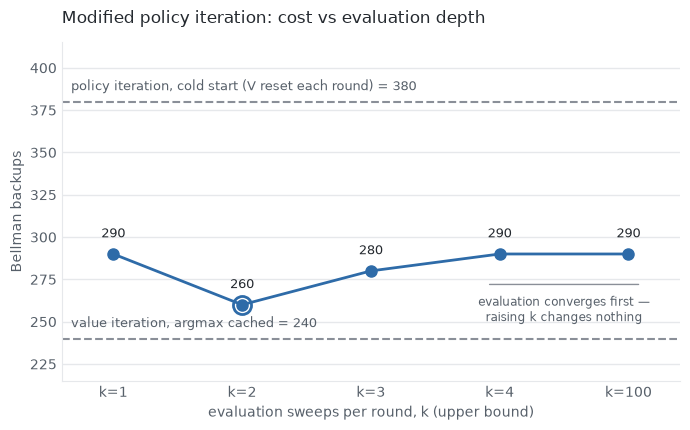

In [1545]:
import matplotlib.pyplot as plt

ks      = ['k=1', 'k=2', 'k=3', 'k=4', 'k=100']
backups = [290, 260, 280, 290, 290]
VI, COLD = 240, 380

INK, MUTED, GRID = '#24292f', '#57606a', '#e6e8eb'
BLUE, GREY = '#2E6BA8', '#8a8f98'

fig, ax = plt.subplots(figsize=(7.0, 4.4))
yt = ax.get_yaxis_transform()

# reference lines: the two things MPI is bracketed by
ax.axhline(COLD, color=GREY, ls='--', lw=1.5, zorder=1)
ax.text(0.015, COLD + 5, 'policy iteration, cold start (V reset each round) = 380',
        transform=yt, fontsize=9, color=MUTED, va='bottom')

ax.axhline(VI, color=GREY, ls='--', lw=1.5, zorder=1)
ax.text(0.015, VI + 5, 'value iteration, argmax cached = 240',
        transform=yt, fontsize=9, color=MUTED, va='bottom')

ax.plot(ks, backups, '-o', color=BLUE, lw=2, ms=8, zorder=3)
ax.plot(['k=2'], [260], 'o', ms=13, mfc='none', mec=BLUE, mew=2, zorder=4)

for x, b in enumerate(backups):
    ax.annotate(f'{b}', (x, b), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=9, color=INK)

# the plateau: evaluation converges before the cap, so k stops mattering
ax.annotate('', xy=(4.1, 272), xytext=(2.9, 272),
            arrowprops=dict(arrowstyle='-', color=GREY, lw=1))
ax.text(3.5, 266, 'evaluation converges first —\nraising k changes nothing',
        ha='center', va='top', fontsize=8.5, color=MUTED)

ax.set_title('Modified policy iteration: cost vs evaluation depth',
             fontsize=12, color=INK, pad=14, loc='left')
ax.set_xlabel('evaluation sweeps per round, k (upper bound)', fontsize=10, color=MUTED)
ax.set_ylabel('Bellman backups', fontsize=10, color=MUTED)
ax.set_ylim(215, 415)
ax.margins(x=0.10)
ax.grid(axis='y', color=GRID, lw=1)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(GRID)
ax.tick_params(colors=MUTED, length=0)

plt.tight_layout()
plt.show()


## Backup accounting

One "backup" = one `grid.step` call = one `reward + gamma * V[s']` evaluation.
The grid has 10 backup-able cells (12 minus the wall at `(1,1)` and the terminal at `(0,3)`).

```-
evaluation sweep                          = 10 cells x 1 action  = 10 backups
improvement sweep                         = 10 cells x 4 actions = 40 backups
improvement sweep (pass_incumbent_policy) =
      10 cells x 4 actions (the argmax)
    + 10 cells x 1 action  (incumbent's q, for the tie-break)
                                                                 = 50 backups
```

### Value iteration

Its `max` computes the argmax and the new value in a single pass, so caching the
argmax during the sweep makes the policy free:

```-
VI (argmax cached)        6 sweeps x 40                      = 240   <- cheapest overall
VI (read_policy after)    6 sweeps x 40 + 1 read_policy x 40  = 280
```

The 280 version is what the first implementation cost: it recomputed the argmax at
the end for a policy it had already derived six times and thrown away.

### Modified policy iteration — measured

Evaluation only runs on rounds `i > 0` (round 0 improves off `V = 0`), so
evals = `(rounds - 1) * sweeps_per_round`.

```-
              rounds   predicted                  measured
k=1              5     5*50 + 4*1*10 = 290          290    exact
k=2              4     4*50 + 3*2*10 = 260          260    exact   <- minimum
k=3              4     4*50 + 3*3*10 = 290          280    10 low
k=4              4                                  290
k=100            4                                  290
cold start       4                                  380
```

### Why k=3 came in 10 under prediction

`k` is an **upper** bound, not a fixed count — the loop is

```-
while delta > 0.001 and i < max_iters and (k is None or i < k)
```

so a late round reached `V^pi` after 2 sweeps and the third never ran: 8 sweeps
total instead of 9. The dial self-limits once evaluation converges.

### Why k=4 and k=100 are identical

Same reason, taken to its conclusion. Warm-started evaluation never needs more
than 4 sweeps here, so every `k >= 4` runs to convergence and costs exactly the
same 290. Raising `k` past that point changes nothing — these are all *true*
policy iteration.

### Why cold start costs 380, not 290

Not an evaluation-depth effect at all. In `policy_iteration`:

```-
V = V if k is not None else None
```

With a numeric `k`, `V` is passed forward and each round's evaluation **resumes**
from the previous round's values. With `k=None`, `policy_evaluation` receives
`None` and resets `V` to zeros, so every round re-derives the value function from
scratch — 18 sweeps across 4 rounds instead of 9 across 3.

So `k=None` is not the `k=inf` endpoint of the curve. It is the same algorithm as
`k >= 4`, paying 90 extra backups (+31%) to rediscover what it already knew.

### The curve

```-
VI            240   <- cheapest
k=1           290
k=2           260   <- MPI minimum
k=3           280
k>=4          290   full evaluation, warm-started
cold start    380   full evaluation, cold-started
```

The textbook result that a middle `k` beats both endpoints holds *within* MPI, but
plain VI beats all of it here. That's because the textbook assumes improvement is
much more expensive than an evaluation sweep — true when `nA` is large or
transitions are stochastic (each backup sums over several next-states). With
`nA = 4` and deterministic moves, improvement is only 4x a sweep, cheap enough
that fusing evaluate-and-improve wins outright. Adding slip should flip this.